In [16]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv(
    "BIDS_FDM2324_Hausarbeit_DS_V0 (1).csv",
    sep=";",
    decimal=",",
    na_values=["NA", "na", ""]
)

print(df.head())
print(df.columns)

    ID Gender  Age Race   BMI Marital status  TypeDiabetes  \
0  502      F   50    1  33.2        married             2   
1  735      M   26    1  31.5        married             2   
2  420      F   50    1  27.6        married             2   
3  680      F   50    3  33.7        married             2   
4  504      M   33    3  18.0        married             2   

   Duration of diabetes (years)  SmokingYears  Amputation  ...  SERUMCRE  \
0                          25.0           0.0           0  ...       1.4   
1                          14.0           0.0           0  ...       NaN   
2                          14.0           0.0           0  ...       2.4   
3                          10.0          30.0           0  ...       1.5   
4                          22.0           0.0           0  ...       1.0   

   MICROALB  SERUMALB                                Hypoglycemic Agents  \
0       NaN     4.000                                      Gansulin 40R    
1       NaN     3.

In [17]:
print(df.isna().sum())

ID                                        0
Gender                                    1
Age                                       0
Race                                      0
BMI                                       0
Marital status                            5
TypeDiabetes                              0
Duration of diabetes (years)            176
SmokingYears                              0
Amputation                                0
SysBP                                     0
DiaBP                                     0
HbA1C                                     0
HDL                                      11
LDL                                       1
TRI                                      12
SERUMCRE                                 12
MICROALB                                206
SERUMALB                                101
Hypoglycemic Agents                     132
Medication Insulin                        0
Medication Sulfonylureas                  0
Medication BP                   

In [18]:
# Standardise column names
df.columns = [c.strip().lower().replace(" ", "_").replace("(", "").replace(")", "") for c in df.columns]

gender_map = {"F": "F", "M": "M", "f": "F", "m": "M"}
df["gender"] = df["gender"].astype(str).str.strip().map(gender_map)  

df["race"] = pd.to_numeric(df["race"], errors="coerce")

In [19]:
#normalise marital status
df["marital_status"] = (
    df["marital_status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"na": np.nan, "unknown": np.nan, "nan": np.nan, "": np.nan})
)

df["duration_of_diabetes_years"] = pd.to_numeric(
    df["duration_of_diabetes_years"], errors="coerce"
)

In [20]:

df["smokingyears"] = pd.to_numeric(df["smokingyears"], errors="coerce")

# Free-text field; standardise whitespace and fix typos
def clean_agents(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.lower() in ("none", "neon", "nan", ""):
        return np.nan
    
    val = re.sub(r"\s{2,}", " ", val)
    val = re.sub(r",\s*", ", ", val)
    return val

df["hypoglycemic_agents"] = df["hypoglycemic_agents"].apply(clean_agents)


In [21]:

numeric_cols = ["sysbp", "diabp", "hba1c", "hdl", "ldl", "tri",
                "serumcre", "microalb", "serumalb", "bmi"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

#make binary binary
binary_cols = ["amputation", "medication_insulin", "medication_sulfonylureas",
               "medication_bp"]
for col in binary_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# Standardise none variants, strip whitespace
for col in ["diabetic_macrovascular_complications",
            "diabetic_microvascular_complications", "comorbidities"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].replace({"none": np.nan, "nan": np.nan, "": np.nan})


In [22]:

# Duplicate ID check
dupes = df[df.duplicated(subset="id", keep=False)]
if not dupes.empty:
    print(f" {len(dupes)} rows share a duplicate ID — review before dropping:")
    print(dupes[["id", "gender", "age", "hba1c"]].to_string())
    
#logic checks
flags = pd.DataFrame(index=df.index)
flags["hba1c_suspicious"] = df["hba1c"].notna() & ~df["hba1c"].between(3, 20)
flags["bmi_suspicious"] = df["bmi"].notna() & ~df["bmi"].between(10, 80)
flags["sysbp_suspicious"] = df["sysbp"].notna() & ~df["sysbp"].between(60, 300)
flags["age_suspicious"] = df["age"].notna() & ~df["age"].between(0, 120)

for col in flags.columns:
    n = flags[col].sum()
    if n:
        print(f" {n} suspicious value(s) in {col}")


 24 rows share a duplicate ID — review before dropping:
      id gender  age  hba1c
22   126      F   33    5.6
30   138    NaN   48    5.8
62   102      F   35    6.4
63   126      M   51    6.4
64   134      F   30    6.4
66   138      F   57    6.4
69   143      M   63    6.4
74   150      F   40    6.5
78   161      F   60    6.6
84   182      M   60    6.6
85   186      M   77    6.7
87   197      F   57    6.7
131   12      M   55    7.7
139  146      M   30    7.8
142   12      M   31    7.9
162  102      F   54    9.0
170  150      F   42   11.7
185  134      F   63    5.8
192  143      F   48    5.9
193  146      F   48    5.9
194  161      M   57    5.9
215  182      F   59    6.2
221  186      F   54    6.3
226  197      M   69    6.4


In [23]:


df["smokingyears"] = df["smokingyears"].round().astype("Int64")
df["duration_of_diabetes_years"] = df["duration_of_diabetes_years"].round().astype("Int64")


for col in ["hypoglycemic_agents", "diabetic_macrovascular_complications",
            "diabetic_microvascular_complications", "comorbidities"]:
    if col in df.columns:
        df[col] = df[col].str.replace(", ", " | ", regex=False)
        
print(f"\nShape: {df.shape}")
print(f"Missing values per column:\n{df.isna().sum()}")




Shape: (285, 26)
Missing values per column:
id                                        0
gender                                    4
age                                       0
race                                      2
bmi                                       0
marital_status                            6
typediabetes                              0
duration_of_diabetes_years              176
smokingyears                              0
amputation                                0
sysbp                                     0
diabp                                     0
hba1c                                     0
hdl                                      11
ldl                                       1
tri                                      12
serumcre                                 12
microalb                                206
serumalb                                101
hypoglycemic_agents                     139
medication_insulin                        0
medication_sulfonylureas       

## How to handle Null values
### General

Gender -> 4 values missing, Create Unknown M/F/U

Race -> 4 values missing, Create Unknown M/F/U

duration of diabetes years -> 176 null values trash

Marital status -> 6, fill with Unknown

### Blood Fats, colesterol stuff
hdl -> 11 fill with median

ldl -> 1 fill with median

tri -> 12 fill with median

### Kidney stuff
serumcre -> 12, fill with median -> likely only kidney marker with enough values

microlabn -> 206 trash, goes in trash

serumalb -> 101 mostly trash, also goes in trash

### Diabetes specific, blood sugar lowering meds
hypogycemic_agents -> 139 goes in the trash

### Conditions 
diabetic_macrovascular_complications -> 173 much but ok because not everybody has a condition

diabetic_microvascular_complications -> 205 same as macrovascular

comorbidities -> other conditions, high null also allowed



In [24]:
df["gender"] = df["gender"].fillna("U")
df["race"] = df["race"].fillna(0)
df["race"] = df["race"].astype("Int64")
df["marital_status"] = df["marital_status"].fillna("unknown")

df["hdl"] = df["hdl"].fillna(df["hdl"].median())
df["ldl"] = df["ldl"].fillna(df["ldl"].median())
df["tri"] = df["tri"].fillna(df["tri"].median())

df["serumcre"] = df["serumcre"].fillna(df["serumcre"].median())

df["diabetic_macrovascular_complications"] = df["diabetic_macrovascular_complications"].fillna(0)
df["diabetic_microvascular_complications"] = df["diabetic_microvascular_complications"].fillna(0)
df["comorbidities"] = df["comorbidities"].fillna(0)

df.drop(columns=["duration_of_diabetes_years", "microalb", "serumalb", "hypoglycemic_agents"], inplace=True)
df.dtypes

id                                        int64
gender                                      str
age                                       int64
race                                      Int64
bmi                                     float64
marital_status                              str
typediabetes                              int64
smokingyears                              Int64
amputation                                Int64
sysbp                                     int64
diabp                                     int64
hba1c                                   float64
hdl                                     float64
ldl                                     float64
tri                                     float64
serumcre                                float64
medication_insulin                        Int64
medication_sulfonylureas                  Int64
medication_bp                             Int64
diabetic_macrovascular_complications     object
diabetic_microvascular_complications    

## clean logically impossible rows
rows that are logically impossible will be considered bad and dropped 

In [25]:
#diabp cant be higher then sysbp
df.drop(df[df['diabp'] >= df['sysbp']].index, inplace = True)
#smoking years cant be higher than age
df.drop(df[df['smokingyears'] >= df['age']].index, inplace = True)
#sysbp cant be over 250, the patient would be dead
df.drop(df[df['sysbp'] >= 250].index, inplace = True)

In [26]:
df.to_csv("cleaned_data.csv", index=False, decimal=".")
print("\nSaved to cleaned_data.csv")


Saved to cleaned_data.csv


In [27]:
print(f"\nShape: {df.shape}")
print(f"Missing values per column:\n{df.isna().sum()}")


Shape: (280, 22)
Missing values per column:
id                                      0
gender                                  0
age                                     0
race                                    0
bmi                                     0
marital_status                          0
typediabetes                            0
smokingyears                            0
amputation                              0
sysbp                                   0
diabp                                   0
hba1c                                   0
hdl                                     0
ldl                                     0
tri                                     0
serumcre                                0
medication_insulin                      0
medication_sulfonylureas                0
medication_bp                           0
diabetic_macrovascular_complications    0
diabetic_microvascular_complications    0
comorbidities                           0
dtype: int64


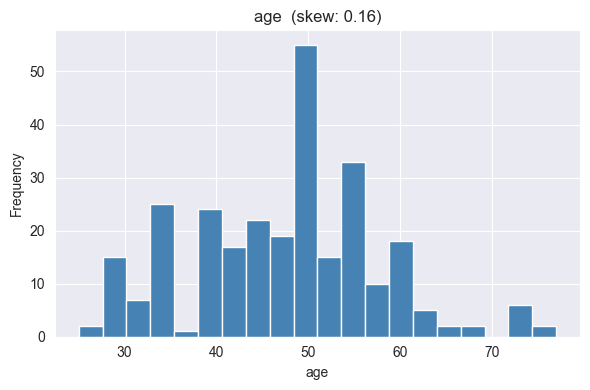

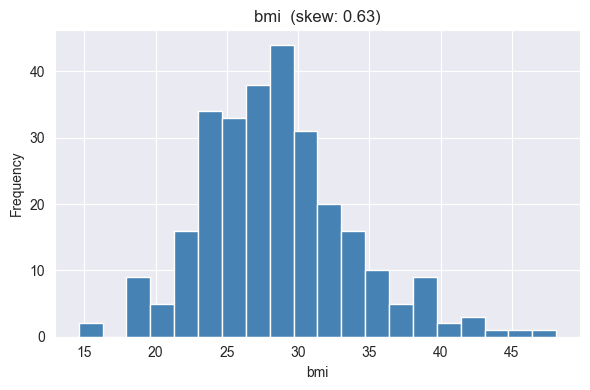

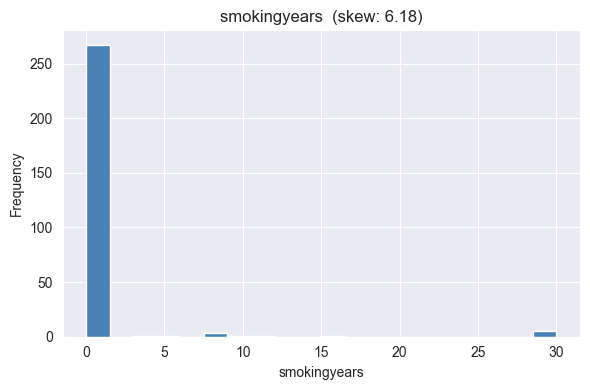

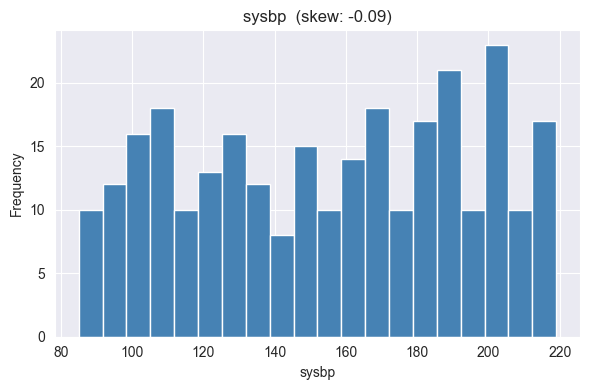

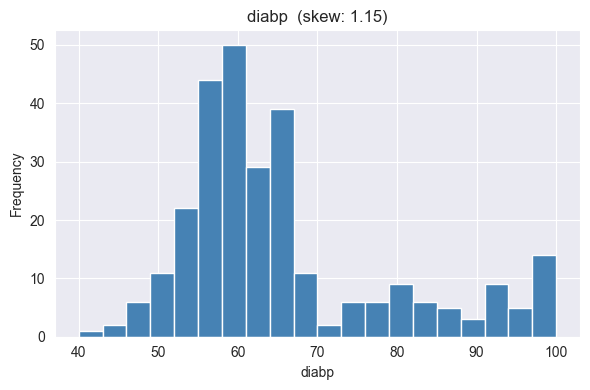

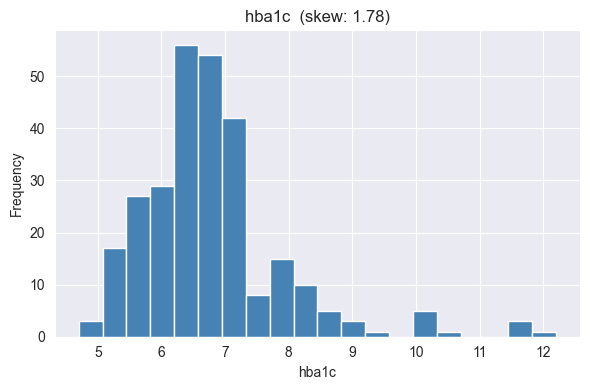

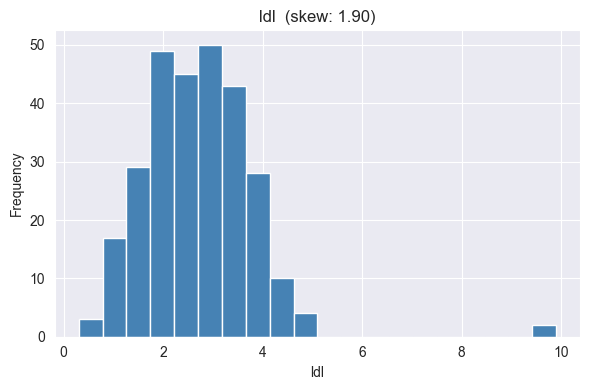

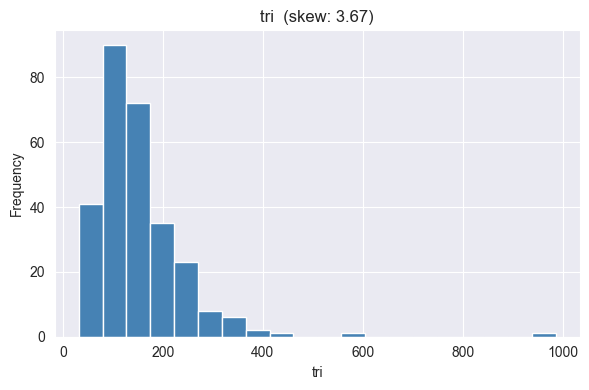

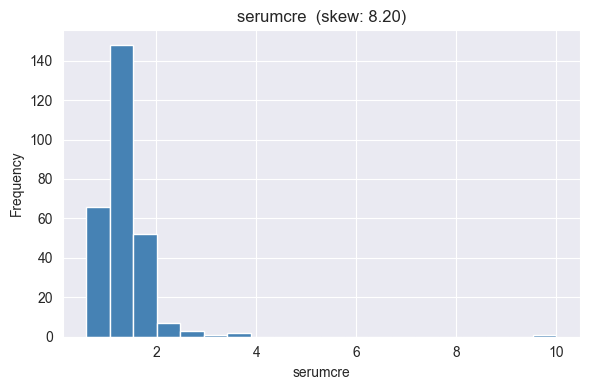

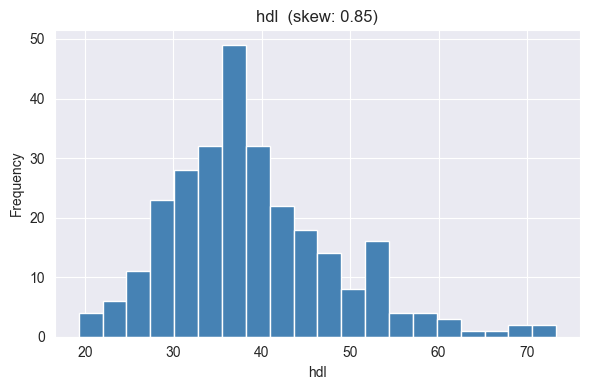

In [28]:

numeric_cols = ["age", "bmi", "smokingyears", "sysbp", "diabp", "hba1c", "ldl", "tri", "serumcre", "hdl"]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].dropna().plot(kind='hist', bins=20, color='steelblue', edgecolor='white')
    plt.title(f"{col}  (skew: {df[col].skew():.2f})")
    plt.xlabel(col)
    plt.tight_layout()
    #plt.savefig(f"skew_{col}.png", dpi=150)
    plt.show()

## skewness handeling

For EDA no skewness handeling is done, only for later modeling skewness needs to be handled 

age -> nothing

sysbp -> nothing

bmi -> moderate skew, Square root transform

hdl -> moderate skew, Square root transform

diabp -> strong skew, log transform

hba1c -> strong skew, log transform

ldl -> strong skew, log transform

tri -> severe skew, Log transform

smokingyears -> severe,  make binary

serumcre -> severe, Log transform

In [29]:
"""import numpy as np
from sklearn.preprocessing import PowerTransformer

# Square root
sqrt_vars = ['bmi', 'hdl']
for col in sqrt_vars:
    df[col + '_sqrt'] = np.sqrt(df[col])

# Log (use log1p to handle any zeros safely)
log_vars = ['diabp', 'hba1c', 'ldl', 'tri', 'serumcre']
for col in log_vars:
    df[col + '_log'] = np.log1p(df[col])

# smokingyears → binary
df['is_smoker'] = (df['smokingyears'] > 0).astype(int)

# Optional: Yeo-Johnson for everything (handles negatives & zeros)
pt = PowerTransformer(method='yeo-johnson')
df[log_vars] = pt.fit_transform(df[log_vars])"""

"import numpy as np\nfrom sklearn.preprocessing import PowerTransformer\n\n# Square root\nsqrt_vars = ['bmi', 'hdl']\nfor col in sqrt_vars:\n    df[col + '_sqrt'] = np.sqrt(df[col])\n\n# Log (use log1p to handle any zeros safely)\nlog_vars = ['diabp', 'hba1c', 'ldl', 'tri', 'serumcre']\nfor col in log_vars:\n    df[col + '_log'] = np.log1p(df[col])\n\n# smokingyears → binary\ndf['is_smoker'] = (df['smokingyears'] > 0).astype(int)\n\n# Optional: Yeo-Johnson for everything (handles negatives & zeros)\npt = PowerTransformer(method='yeo-johnson')\ndf[log_vars] = pt.fit_transform(df[log_vars])"

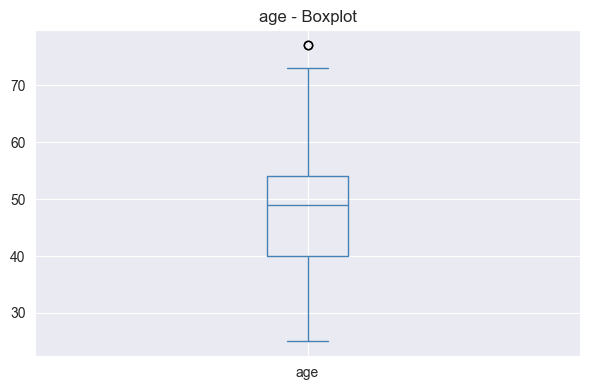

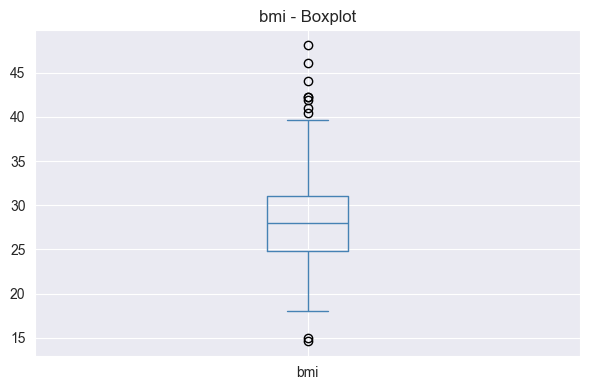

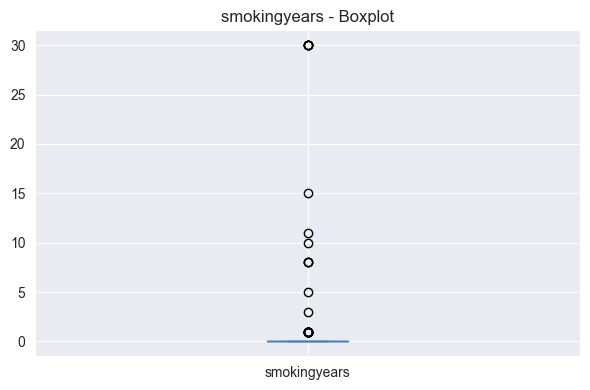

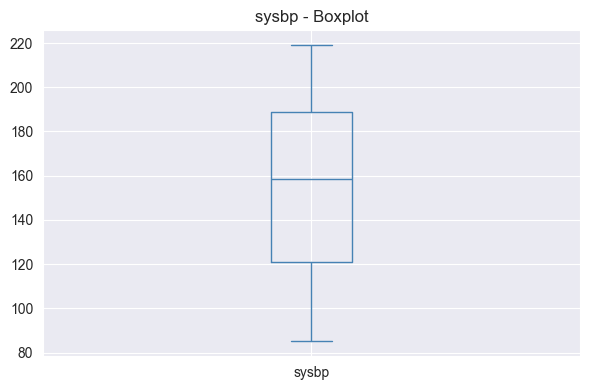

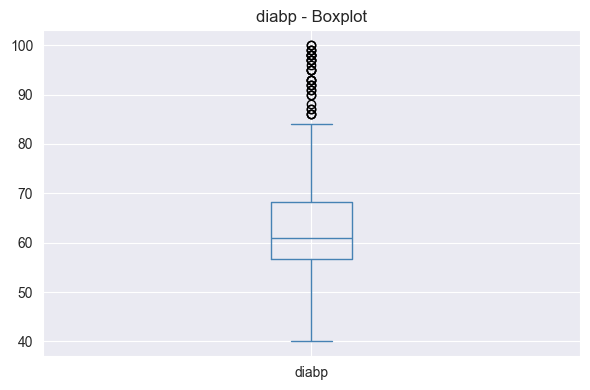

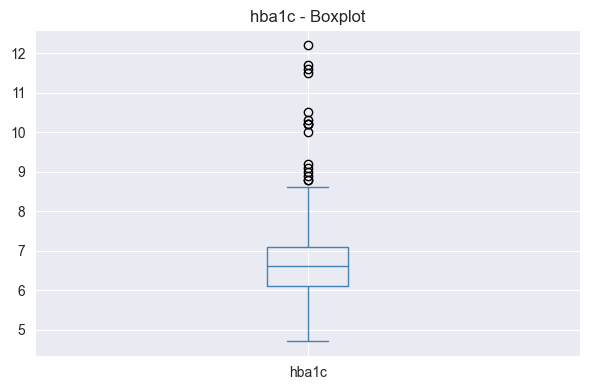

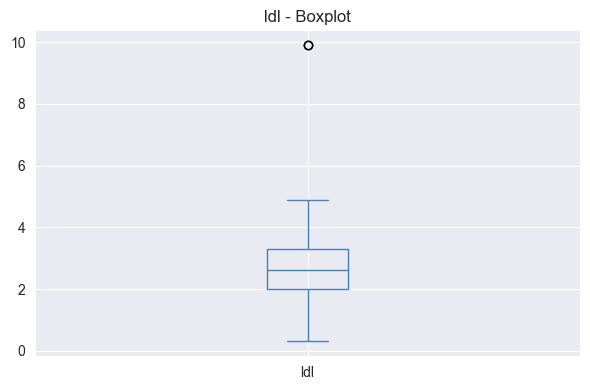

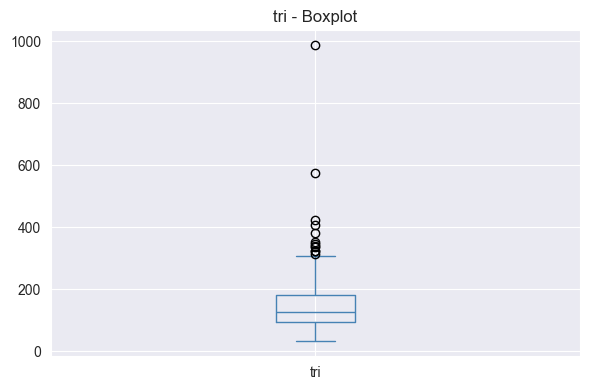

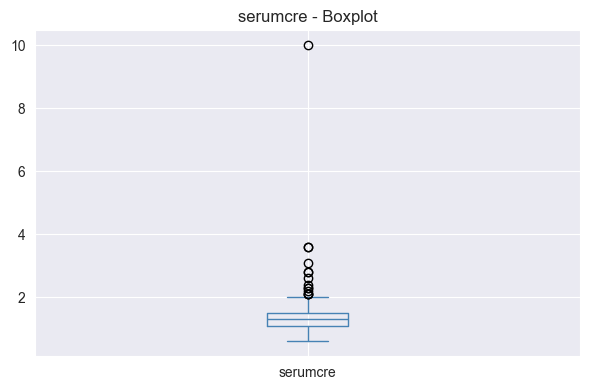

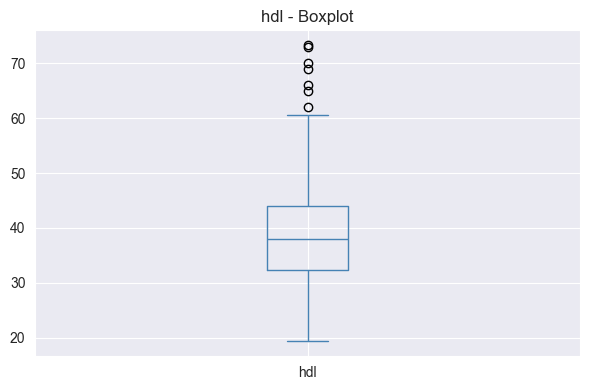

In [30]:
numeric_cols = ["age", "bmi", "smokingyears", "sysbp", "diabp", "hba1c", "ldl", "tri", "serumcre", "hdl"]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].dropna().plot(kind='box', color='steelblue')
    plt.title(f"{col} - Boxplot")
    plt.tight_layout()
    plt.show()

outliers: 

in most of the blood value measures severely elevated levels are expected, and provide valuable insight since all the patients in this dataset have type 2 diabetes

### IQR Score and Z Score

In [32]:

numeric_cols = ["age", "bmi", "smokingyears", "sysbp", "diabp", "hba1c", "ldl", "tri", "serumcre", "hdl"]
 
records = []
 
for col in numeric_cols:
    series = df[col].dropna()
    if len(series) < 2:
        continue
 
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo_mild,  hi_mild  = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    lo_ext,   hi_ext   = q1 - 3.0 * iqr, q3 + 3.0 * iqr
    z_scores = np.abs(stats.zscore(series))
 
    for i, (idx, val) in enumerate(series.items()):
        z = z_scores[i]
 
        iqr_flag = ("extreme" if val < lo_ext  or val > hi_ext  else
                    "mild"    if val < lo_mild or val > hi_mild else None)
        z_flag   = ("extreme" if z > 3 else
                    "mild"    if z > 2 else None)
 
        if iqr_flag or z_flag:
            records.append({
                "row_index": idx,
                "column":    col,
                "value":     round(val, 4),
                "IQR_flag":  iqr_flag or "ok",
                "Z_score":   round(z, 2),
                "Z_flag":    z_flag or "ok",
            })
 
result = pd.DataFrame(records)
 
if result.empty:
    print("No outliers detected.")
else:
    print(result.to_string(index=False))



 row_index       column    value IQR_flag  Z_score  Z_flag
         1          age  26.0000       ok     2.09    mild
        72          age  25.0000       ok     2.19    mild
        79          age  77.0000     mild     2.88    mild
        85          age  77.0000     mild     2.88    mild
       222          age  69.0000       ok     2.10    mild
       226          age  69.0000       ok     2.10    mild
       235          age  73.0000       ok     2.49    mild
       241          age  73.0000       ok     2.49    mild
       242          age  73.0000       ok     2.49    mild
       246          age  73.0000       ok     2.49    mild
       263          age  73.0000       ok     2.49    mild
       270          age  73.0000       ok     2.49    mild
        38          bmi  39.2000       ok     2.03    mild
        73          bmi  42.3000     mild     2.62    mild
        79          bmi  39.3000       ok     2.05    mild
        88          bmi  44.1000     mild     2.96    mi